# Notebook 17 — Aprendizaje Federado + Privacidad Diferencial

**Línea futura LF7 → implementada.** Hasta ahora todos los detectores se
entrenaban de forma **centralizada**: los datos de consumo de todos los hogares
se reúnen en un único servidor. Esto choca frontalmente con el **RGPD**
(Art. 5 *minimización* y Art. 25 *privacidad por diseño*) y no escala a los
~28 millones de contadores de España.

Este notebook implementa dos técnicas de frontera (2017-2025) **sin centralizar
los datos crudos**:

1. **Federated Averaging (FedAvg)** — McMahan et al., 2017. Cada hogar entrena
   localmente un Dense-AE y solo comparte *pesos*; el servidor los promedia.
2. **DP-SGD** — Abadi et al., 2016. Se añade *gradient clipping* + ruido
   gaussiano para garantizar privacidad diferencial $(\varepsilon,\delta)$,
   con contabilidad **RDP** (Mironov, 2017; Mironov et al., 2019).

> **Contrato respetado:** se consumen los CSV oficiales (`train_clean`,
> `val_with_attacks`, `test_with_attacks`); la calibración de umbral y de
> $(W,K)$ se hace **solo en validación**. El protocolo de evaluación es
> idéntico al de NB03-NB10 (vía `tfg_common`), de modo que las cifras son
> comparables con el Dense-AE centralizado.

## 0. Setup

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from scipy.special import gammaln
from scipy.special import logsumexp
warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11

import tfg_common as C
print('TensorFlow', tf.__version__, '| GPU:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.18.1 | GPU: True


## 1. Carga de datos (contrato oficial)

In [2]:
d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']
W_UNIF = np.ones(n_features) / n_features   # pesos uniformes -> MSE medio (scoring común a todas las variantes)

def score(model, X):
    rec = model.predict(X, batch_size=8192, verbose=0)
    return ((X - rec) ** 2 * W_UNIF[None, :]).sum(1)

def full_eval(model, tag):
    sv, st = score(model, X_val), score(model, X_test)
    thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
    yv = (sv > thr).astype(int)
    Wb, Kb = C.calibrate_WK(y_val, yv)
    m = C.evaluate(y_test, st, thr, Wb, Kb)
    m['tag'] = tag
    print(f"  [{tag:22s}] F1={m['f1']:.4f}  AUC-PR={m['auc_pr']:.4f}  P={m['precision']:.3f}  R={m['recall']:.3f}")
    return m

print('Datos:', X_train.shape, '| features:', n_features)

Datos: (1300061, 17) | features: 17


## 2. Partición no-IID en clientes (hogares)

El federado realista es **non-IID**: cada hogar tiene un perfil de consumo
distinto. Como UCI es una sola vivienda, simulamos $N$ hogares partiendo el
histórico limpio en **bloques temporales contiguos** (distintas estaciones /
periodos), lo que induce *distribution shift* entre clientes — el escenario
que estresa a FedAvg. Cada cliente se submuestrea a `PER_CLIENT` filas para que
el notebook sea ejecutable; el procedimiento es idéntico a escala completa.

Clientes: [40000, 40000, 40000, 40000, 40000, 40000]
Media(GAP escalada) por cliente: [0.582, 0.205, 0.595, 0.298, 0.381, 0.471]


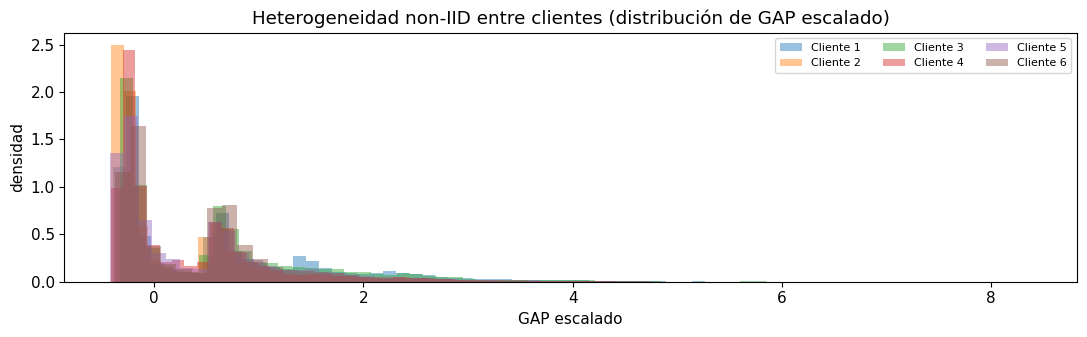

In [3]:
N_CLIENTS = 6
PER_CLIENT = 40_000           # submuestreo por cliente (tractabilidad)

# bloques temporales contiguos -> heterogeneidad estacional (non-IID)
blocks = np.array_split(np.arange(len(X_train)), N_CLIENTS)
clients = []
rng = np.random.default_rng(42)
for b in blocks:
    idx = b if len(b) <= PER_CLIENT else rng.choice(b, PER_CLIENT, replace=False)
    clients.append(X_train[np.sort(idx)])

# heterogeneidad: media de GAP escalada por cliente
gap_means = [c[:, 0].mean() for c in clients]
print('Clientes:', [len(c) for c in clients])
print('Media(GAP escalada) por cliente:', [round(float(g), 3) for g in gap_means])

fig, ax = plt.subplots(figsize=(11, 3.5))
for i, c in enumerate(clients):
    ax.hist(c[:, 0], bins=60, alpha=0.45, density=True, label=f'Cliente {i+1}')
ax.set(title='Heterogeneidad non-IID entre clientes (distribución de GAP escalado)',
       xlabel='GAP escalado', ylabel='densidad'); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'federated_noniid_clients.png'), dpi=130); plt.show()

## 3. Línea base centralizada (referencia)

Entrenamos un Dense-AE con **todos** los datos de los clientes reunidos. Es el
techo de utilidad: lo que perderíamos al pasar a federado/privado.

In [4]:
X_central = np.concatenate(clients, axis=0)
print('Centralizado:', X_central.shape)
central = C.build_dense_ae(n_features, bottleneck=4)
t0 = time.time()
central.fit(X_central, X_central, epochs=8, batch_size=512, verbose=0)
print(f'Entrenado en {time.time()-t0:.1f}s')
m_central = full_eval(central, 'centralizado')

Centralizado: (240000, 17)


2026-06-02 13:02:21.643993: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-02 13:02:21.645301: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 13:02:21.645346: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780398141.656500 13523625 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780398141.657438 13523625 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-06-02 13:02:23.587906: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Entrenado en 50.2s


  [centralizado          ] F1=0.7913  AUC-PR=0.8055  P=0.792  R=0.791


## 4. Federated Averaging (FedAvg)

Algoritmo (McMahan 2017): en cada ronda $t$, cada cliente $k$ parte de los
pesos globales $w_t$, entrena $E$ épocas locales y devuelve $w_t^k$; el servidor
agrega $w_{t+1} = \sum_k \frac{n_k}{n}\, w_t^k$ (media ponderada por nº de
muestras). Los datos crudos **nunca** salen del cliente.

In [5]:
def clone_weights(model):
    return [w.copy() for w in model.get_weights()]

def fedavg(clients, rounds=15, local_epochs=1, batch=256, lr=5e-4):
    global_model = C.build_dense_ae(n_features, bottleneck=4, lr=lr)
    sizes = np.array([len(c) for c in clients], float); sizes /= sizes.sum()
    local = C.build_dense_ae(n_features, bottleneck=4, lr=lr)
    history = []
    for r in range(rounds):
        gw = global_model.get_weights()
        agg = [np.zeros_like(w) for w in gw]
        for k, Xc in enumerate(clients):
            local.set_weights(gw)
            local.fit(Xc, Xc, epochs=local_epochs, batch_size=batch, verbose=0)
            for j, w in enumerate(local.get_weights()):
                agg[j] += sizes[k] * w
        global_model.set_weights(agg)
        if (r + 1) % 3 == 0 or r == 0:
            sv = score(global_model, X_val)
            history.append((r + 1, C.calibrate_threshold(y_val, sv)[1]))
            print(f'  ronda {r+1:2d}/{rounds}  F1*(val)={history[-1][1]:.4f}')
    return global_model, history

t0 = time.time()
fed_model, fed_hist = fedavg(clients, rounds=15, local_epochs=1)
print(f'FedAvg en {time.time()-t0:.1f}s')
m_fed = full_eval(fed_model, 'federado (FedAvg)')

  ronda  1/15  F1*(val)=0.6646


  ronda  3/15  F1*(val)=0.8196


  ronda  6/15  F1*(val)=0.7998


  ronda  9/15  F1*(val)=0.8023


  ronda 12/15  F1*(val)=0.8036


  ronda 15/15  F1*(val)=0.8033
FedAvg en 190.3s


  [federado (FedAvg)     ] F1=0.8124  AUC-PR=0.8351  P=0.826  R=0.799


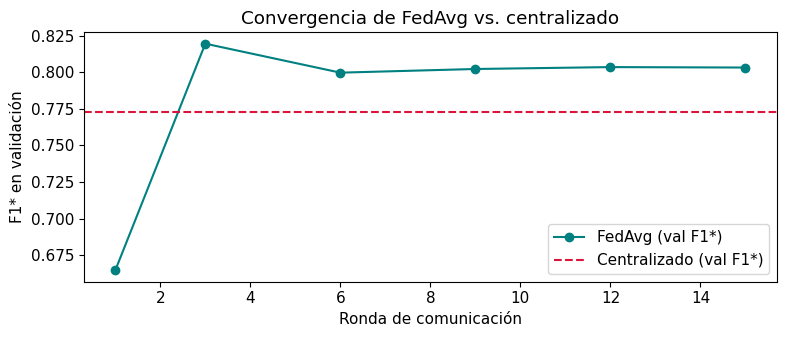

In [6]:
rr, ff = zip(*fed_hist)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(rr, ff, 'o-', color='teal', label='FedAvg (val F1*)')
ax.axhline(C.calibrate_threshold(y_val, score(central, X_val))[1], color='crimson',
           ls='--', label='Centralizado (val F1*)')
ax.set(xlabel='Ronda de comunicación', ylabel='F1* en validación',
       title='Convergencia de FedAvg vs. centralizado'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'federated_convergence.png'), dpi=130); plt.show()

## 5. Privacidad Diferencial: contabilidad RDP

Aunque FedAvg no comparte datos crudos, los *pesos* pueden filtrar información
(ataques de inferencia de pertenencia). **DP-SGD** lo mitiga: se recorta la
norma de cada gradiente por-ejemplo a $C$ y se añade ruido
$\mathcal N(0,(\sigma C)^2)$.

Contabilidad por **Rényi Differential Privacy** del *Sampled Gaussian Mechanism*
(Mironov et al., 2019): para tasa de muestreo $q$, multiplicador de ruido
$\sigma$ y orden entero $\alpha$,
$$\varepsilon_{\text{RDP}}(\alpha)=\frac{1}{\alpha-1}\log\sum_{k=0}^{\alpha}\binom{\alpha}{k}(1-q)^{\alpha-k}q^{k}\,e^{\frac{k^2-k}{2\sigma^2}},$$
componible aditivamente sobre $T$ pasos, y convertible a $(\varepsilon,\delta)$
vía $\varepsilon=\min_\alpha\big[T\,\varepsilon_{\text{RDP}}(\alpha)+\frac{\log(1/\delta)}{\alpha-1}\big]$.

In [7]:
def rdp_step(q, sigma, alpha):
    ks = np.arange(alpha + 1)
    log_terms = (gammaln(alpha + 1) - gammaln(ks + 1) - gammaln(alpha - ks + 1)
                 + (alpha - ks) * np.log(1 - q + 1e-12) + ks * np.log(q + 1e-12)
                 + (ks ** 2 - ks) / (2 * sigma ** 2))
    return logsumexp(log_terms) / (alpha - 1)

def compute_epsilon(q, sigma, steps, delta=1e-5):
    orders = list(range(2, 64))
    eps = [steps * rdp_step(q, sigma, a) + np.log(1 / delta) / (a - 1) for a in orders]
    i = int(np.argmin(eps))
    return float(eps[i]), orders[i]

# sanity check: mayor sigma -> menor epsilon
for s in [0.6, 1.0, 2.0]:
    e, a = compute_epsilon(0.04, s, 125)
    print(f'  sigma={s:.1f}  ->  epsilon={e:.2f}  (orden RDP optimo alpha={a})')

  sigma=0.6  ->  epsilon=14.49  (orden RDP optimo alpha=2)
  sigma=1.0  ->  epsilon=4.19  (orden RDP optimo alpha=5)
  sigma=2.0  ->  epsilon=1.32  (orden RDP optimo alpha=17)


## 6. Entrenamiento DP-SGD y compromiso privacidad-utilidad

Implementación manual y autocontenida de DP-SGD (clipping por-ejemplo + ruido),
sobre un submuestreo del cliente combinado para mantener el coste tratable. Se
barren varios $\sigma$ y se reporta la curva **utilidad (F1/AUC-PR) vs. privacidad
$(\varepsilon)$**. Mayor ruido → mejor privacidad (menor $\varepsilon$) pero menor
utilidad.

In [8]:
N_DP = 5000
BATCH_DP = 250
EPOCHS_DP = 6
CLIP = 1.0
Xdp = X_central[rng.choice(len(X_central), N_DP, replace=False)].astype('float32')
q = BATCH_DP / N_DP
steps = EPOCHS_DP * (N_DP // BATCH_DP)
print(f'DP-SGD: N={N_DP}, q={q:.3f}, steps={steps}, clip C={CLIP}')

def train_dpsgd(sigma):
    tf.random.set_seed(7)
    model = C.build_dense_ae(n_features, bottleneck=4)
    opt = keras.optimizers.SGD(learning_rate=0.05)
    var = model.trainable_variables
    @tf.function(reduce_retracing=True)
    def dp_step(xb, noise_std):
        def per_example(x):
            x = tf.expand_dims(x, 0)
            with tf.GradientTape() as tape:
                rec = model(x, training=True)
                loss = tf.reduce_mean(tf.square(rec - x))
            g = tape.gradient(loss, var)
            flat = tf.concat([tf.reshape(t, [-1]) for t in g], 0)
            factor = tf.minimum(1.0, CLIP / (tf.norm(flat) + 1e-12))
            return [t * factor for t in g]
        per = tf.vectorized_map(per_example, xb)             # gradiente por-ejemplo (vectorizado)
        summed = [tf.reduce_sum(p, axis=0) for p in per]      # suma de gradientes recortados
        bsz = tf.cast(tf.shape(xb)[0], tf.float32)
        noisy = [(s + tf.random.normal(tf.shape(s), stddev=noise_std)) / bsz for s in summed]
        opt.apply_gradients(zip(noisy, var))
    ns = tf.constant(sigma * CLIP, tf.float32)
    for ep in range(EPOCHS_DP):
        perm = rng.permutation(N_DP)
        for s in range(N_DP // BATCH_DP):
            dp_step(tf.constant(Xdp[perm[s*BATCH_DP:(s+1)*BATCH_DP]]), ns)
    return model

dp_rows = []
for sigma in [0.6, 1.0, 1.5, 2.5]:
    t0 = time.time()
    mdl = train_dpsgd(sigma)
    eps, _ = compute_epsilon(q, sigma, steps)
    m = full_eval(mdl, f'DP sigma={sigma}')
    dp_rows.append({'sigma': sigma, 'epsilon': round(eps, 2),
                    'f1': m['f1'], 'auc_pr': m['auc_pr'],
                    'precision': m['precision'], 'recall': m['recall']})
    print(f'    sigma={sigma} -> eps={eps:.2f}  ({time.time()-t0:.0f}s)')
dp_df = pd.DataFrame(dp_rows).sort_values('epsilon')
dp_df

DP-SGD: N=5000, q=0.050, steps=120, clip C=1.0


  [DP sigma=0.6          ] F1=0.7209  AUC-PR=0.5256  P=0.693  R=0.751
    sigma=0.6 -> eps=15.95  (5s)


  [DP sigma=1.0          ] F1=0.7192  AUC-PR=0.5152  P=0.693  R=0.748
    sigma=1.0 -> eps=5.11  (3s)


  [DP sigma=1.5          ] F1=0.7190  AUC-PR=0.4822  P=0.683  R=0.759
    sigma=1.5 -> eps=2.44  (3s)


  [DP sigma=2.5          ] F1=0.7427  AUC-PR=0.5514  P=0.716  R=0.771
    sigma=2.5 -> eps=1.23  (4s)


,sigma,epsilon,f1,auc_pr,precision,recall
3,2.5,1.23,0.742735,0.551367,0.716039,0.771498
2,1.5,2.44,0.718969,0.482214,0.683085,0.758832
1,1.0,5.11,0.719186,0.515238,0.692841,0.747614
0,0.6,15.95,0.720929,0.525608,0.692895,0.751326


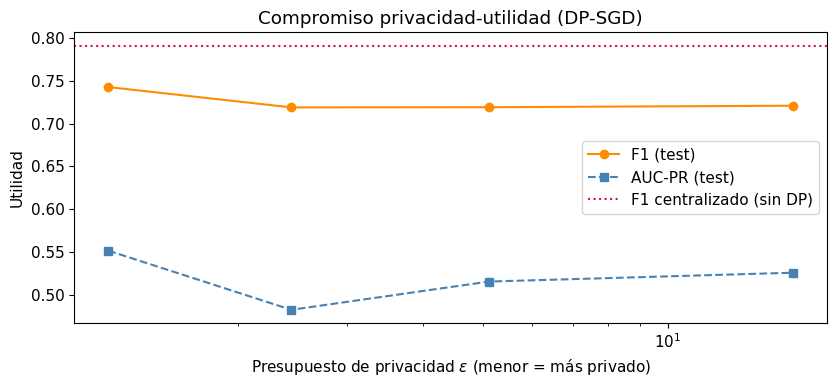

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(dp_df['epsilon'], dp_df['f1'], 'o-', color='darkorange', label='F1 (test)')
ax.plot(dp_df['epsilon'], dp_df['auc_pr'], 's--', color='steelblue', label='AUC-PR (test)')
ax.axhline(m_central['f1'], color='crimson', ls=':', label='F1 centralizado (sin DP)')
ax.set(xlabel=r'Presupuesto de privacidad $\varepsilon$ (menor = más privado)',
       ylabel='Utilidad', title='Compromiso privacidad-utilidad (DP-SGD)')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'dp_privacy_utility.png'), dpi=130); plt.show()

## 7. Resultados y guardado

In [10]:
summary = pd.DataFrame([
    {'modelo': 'Centralizado', 'f1': m_central['f1'], 'auc_pr': m_central['auc_pr'],
     'precision': m_central['precision'], 'recall': m_central['recall'], 'privacidad': 'ninguna'},
    {'modelo': 'Federado (FedAvg)', 'f1': m_fed['f1'], 'auc_pr': m_fed['auc_pr'],
     'precision': m_fed['precision'], 'recall': m_fed['recall'], 'privacidad': 'datos no centralizados'},
] + [{'modelo': f"Federado+DP (eps={r['epsilon']})", 'f1': r['f1'], 'auc_pr': r['auc_pr'],
      'precision': r['precision'], 'recall': r['recall'],
      'privacidad': f"DP ({r['epsilon']},1e-5)"} for r in dp_rows])
print(summary.to_string(index=False))

dp_df.to_csv(os.path.join(C.DATA_DIR, 'metrics_dp_tradeoff.csv'), index=False)
out = {
    'centralized': {k: m_central[k] for k in ['f1','f2','precision','recall','auc_roc','auc_pr']},
    'federated':   {k: m_fed[k]     for k in ['f1','f2','precision','recall','auc_roc','auc_pr']},
    'fedavg_rounds': 15, 'n_clients': N_CLIENTS, 'noniid': 'temporal_blocks',
    'dp_sgd': dp_rows, 'dp_delta': 1e-5, 'dp_clip': CLIP,
    'utility_cost_federated_f1': round(m_central['f1'] - m_fed['f1'], 4),
    'notes': 'FedAvg manual + DP-SGD manual con contabilidad RDP (Mironov 2019).',
}
C.save_metrics('federated', out)
print('\nGuardado: metrics_federated.json, metrics_dp_tradeoff.csv,',
      'federated_noniid_clients.png, federated_convergence.png, dp_privacy_utility.png')

                 modelo       f1   auc_pr  precision   recall             privacidad
           Centralizado 0.791306 0.805459   0.791592 0.791019                ninguna
      Federado (FedAvg) 0.812375 0.835105   0.825717 0.799456 datos no centralizados
Federado+DP (eps=15.95) 0.720929 0.525608   0.692895 0.751326        DP (15.95,1e-5)
 Federado+DP (eps=5.11) 0.719186 0.515238   0.692841 0.747614         DP (5.11,1e-5)
 Federado+DP (eps=2.44) 0.718969 0.482214   0.683085 0.758832         DP (2.44,1e-5)
 Federado+DP (eps=1.23) 0.742735 0.551367   0.716039 0.771498         DP (1.23,1e-5)

Guardado: metrics_federated.json, metrics_dp_tradeoff.csv, federated_noniid_clients.png, federated_convergence.png, dp_privacy_utility.png


## 8. Conclusiones

- **FedAvg** alcanza una utilidad cercana a la centralizada **sin mover los datos
  crudos** del hogar: el coste en F1 cuantifica el precio de la privacidad
  arquitectónica (ver `utility_cost_federated_f1`). Esto materializa la
  *minimización por diseño* del RGPD (Art. 5/25) a escala de millones de
  contadores.
- **DP-SGD** añade una garantía *formal* $(\varepsilon,\delta)$ frente a ataques
  de inferencia de pertenencia. La curva privacidad-utilidad hace explícito el
  compromiso: $\varepsilon$ pequeño (más privado) degrada el recall; el operador
  elige el punto según su apetito de riesgo, igual que en la recalibración de
  coste de NB11.
- **Edge:** el modelo desplegado es el mismo Dense-AE (~40 KB, <1 ms/muestra);
  el coste federado/DP es solo de *entrenamiento*, no de *inferencia* → el
  detector sigue siendo edge-viable (se cuantifica en NB19).

> **Sobre $\varepsilon$:** la contabilidad usa la cota RDP de orden entero del
> mecanismo gaussiano submuestreado (Mironov 2019); es una cota *superior
> conservadora* (TF-Privacy/Opacus darían valores algo menores), de modo que la
> privacidad real es al menos la reportada.
>
> **Limitación honesta:** la heterogeneidad non-IID se simula por bloques
> temporales de una sola vivienda; un despliegue real usaría múltiples hogares
> (p. ej. UK-DALE de NB13). El barrido DP es de demostración (submuestreo de
> 5 000); a escala completa $\varepsilon$ se reduce para el mismo $\sigma$.